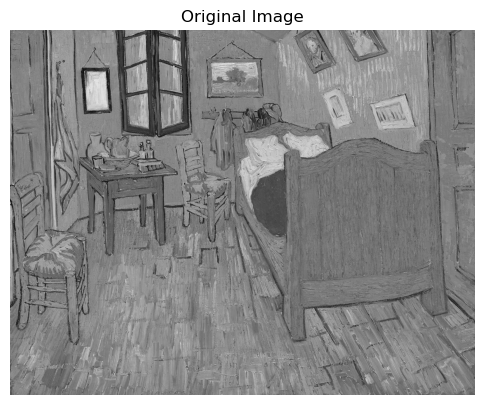

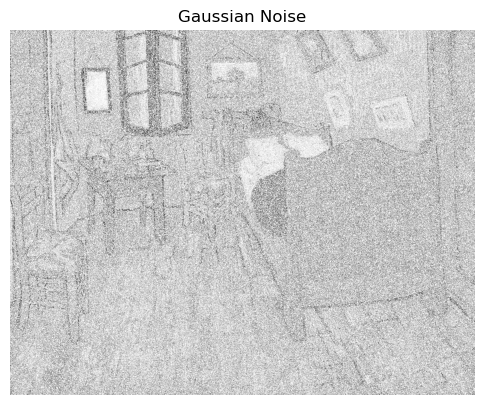

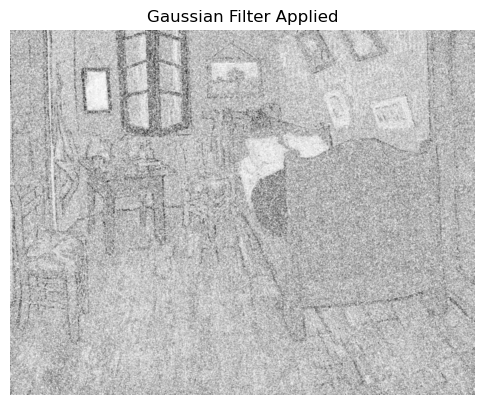

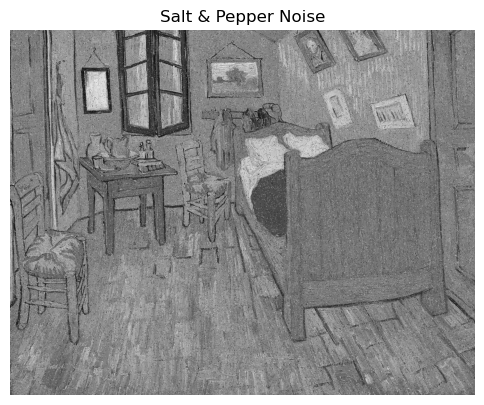

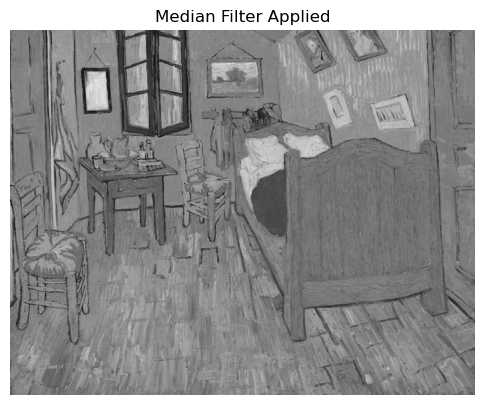

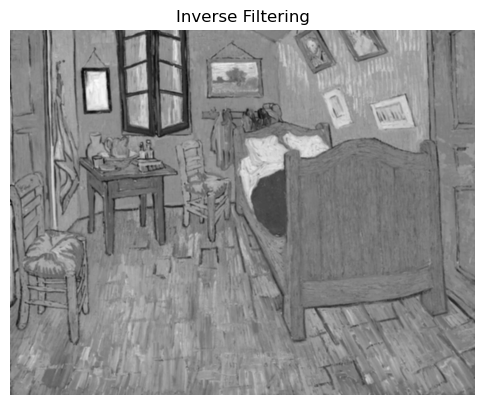

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Image
def load_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return image

# Display Image
def show_image(image, title="Image"):
    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Add Gaussian Noise
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, noise)
    return noisy_image

# Apply Gaussian Filter
def gaussian_filter(image, kernel_size=5):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

# Apply Median Filter
def median_filter(image, kernel_size=3):
    return cv2.medianBlur(image, kernel_size)

# Apply Adaptive Filter
def adaptive_filter(image, d=9, sigmaColor=75, sigmaSpace=75):
    return cv2.bilateralFilter(image, d, sigmaColor, sigmaSpace)

# Add Salt-and-Pepper Noise
def add_salt_and_pepper_noise(image, salt_prob=0.02, pepper_prob=0.02):
    noisy_image = np.copy(image)
    total_pixels = image.size
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)

    salt_coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    pepper_coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]

    noisy_image[salt_coords[0], salt_coords[1]] = 255
    noisy_image[pepper_coords[0], pepper_coords[1]] = 0

    return noisy_image

# Inverse Filtering (Simple Deconvolution)
def inverse_filtering(image, kernel_size=5):
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size ** 2)
    return cv2.filter2D(image, -1, kernel)

# Load and Apply Functions
image_path = "C:/Users/student/Documents/Computer Vision 2023510051/VanGoghRoom.jpg"
image = load_image(image_path)
show_image(image, "Original Image")

noisy_image = add_gaussian_noise(image)
show_image(noisy_image, "Gaussian Noise")

filtered_image = gaussian_filter(noisy_image)
show_image(filtered_image, "Gaussian Filter Applied")

sp_noisy_image = add_salt_and_pepper_noise(image)
show_image(sp_noisy_image, "Salt & Pepper Noise")

median_filtered = median_filter(sp_noisy_image)
show_image(median_filtered, "Median Filter Applied")

inverse_filtered = inverse_filtering(image)
show_image(inverse_filtered, "Inverse Filtering")


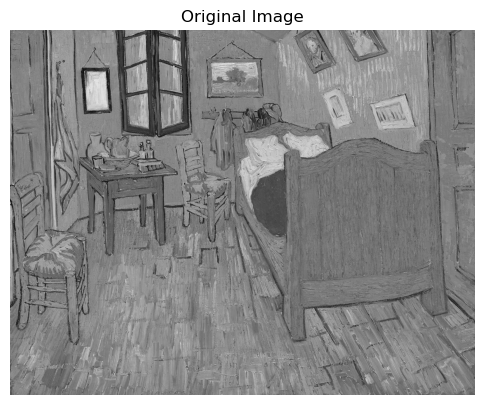

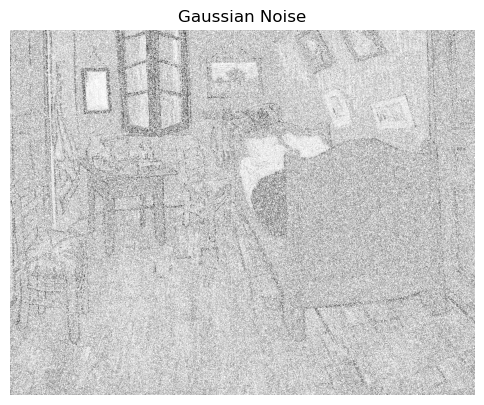

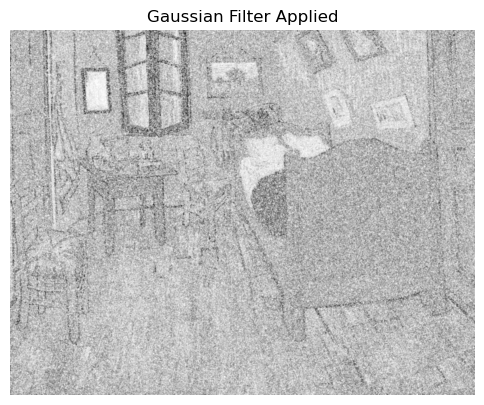

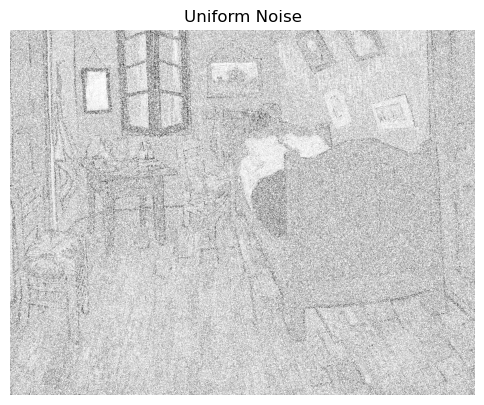

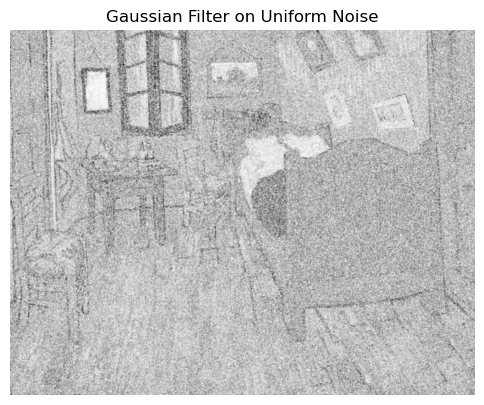

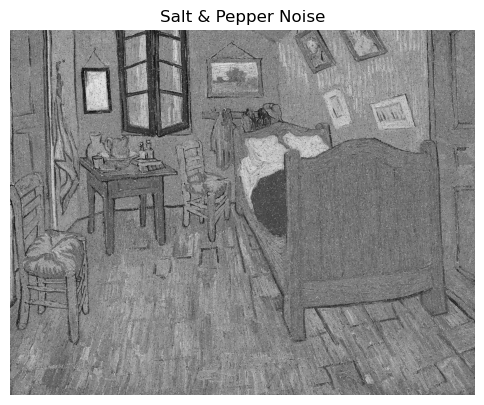

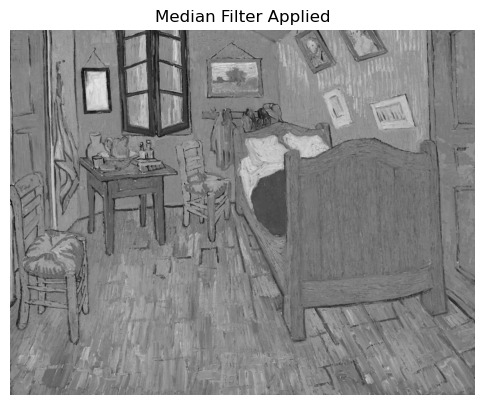

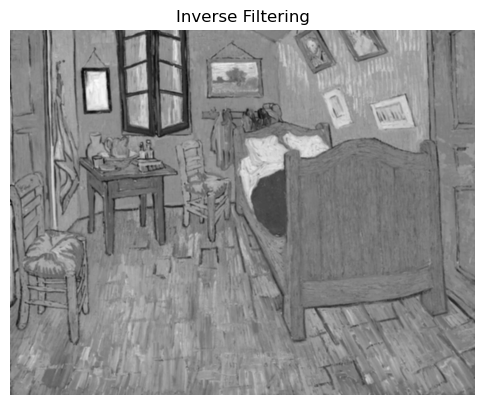

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return image

def show_image(image, title="Image"):
    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Noise Functions
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, noise)
    return noisy_image

# Inference: Gaussian noise occurs due to electronic circuits and is best handled using Gaussian filters. It is random and follows a normal distribution.

def add_uniform_noise(image, a=-50, b=50):
    noise = np.random.uniform(a, b, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, noise)
    return noisy_image

# Inference: Uniform noise is artificially generated and rarely encountered in real applications. It distributes noise evenly, making it useful for testing restoration algorithms.

def add_salt_and_pepper_noise(image, salt_prob=0.02, pepper_prob=0.02):
    noisy_image = np.copy(image)
    total_pixels = image.size
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)
    
    salt_coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    pepper_coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    
    noisy_image[salt_coords[0], salt_coords[1]] = 255
    noisy_image[pepper_coords[0], pepper_coords[1]] = 0
    
    return noisy_image

# Inference: Salt-and-pepper noise results from transmission errors or sensor malfunctions, appearing as white and black pixels. Median filtering effectively removes it.

# Filter Functions
def gaussian_filter(image, kernel_size=5):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

# Inference: Gaussian filtering smooths noise and detail, making it useful for pre-processing. However, it may blur fine structures.

def median_filter(image, kernel_size=3):
    return cv2.medianBlur(image, kernel_size)

# Inference: Median filtering removes salt-and-pepper noise while preserving edges, making it ideal for high-frequency noise suppression.

def adaptive_filter(image, d=9, sigmaColor=75, sigmaSpace=75):
    return cv2.bilateralFilter(image, d, sigmaColor, sigmaSpace)

# Inference: Adaptive filters selectively smooth regions with low variance while preserving edges, making them more effective than simple smoothing.

def inverse_filtering(image, kernel_size=5):
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size ** 2)
    return cv2.filter2D(image, -1, kernel)

# Inference: Inverse filtering restores degraded images by reversing blur, but it is sensitive to noise and requires precise degradation models.

# Load and Apply Filters
i_path = "C:/Users/student/Documents/Computer Vision 2023510051/VanGoghRoom.jpg"
image = load_image(i_path)
show_image(image, "Original Image")

noisy_gaussian = add_gaussian_noise(image)
show_image(noisy_gaussian, "Gaussian Noise")
filtered_gaussian = gaussian_filter(noisy_gaussian)
show_image(filtered_gaussian, "Gaussian Filter Applied")

noisy_uniform = add_uniform_noise(image)
show_image(noisy_uniform, "Uniform Noise")
filtered_uniform = gaussian_filter(noisy_uniform)
show_image(filtered_uniform, "Gaussian Filter on Uniform Noise")

noisy_sp = add_salt_and_pepper_noise(image)
show_image(noisy_sp, "Salt & Pepper Noise")
filtered_median = median_filter(noisy_sp)
show_image(filtered_median, "Median Filter Applied")

inverse_filtered = inverse_filtering(image)
show_image(inverse_filtered, "Inverse Filtering")
